# ML-testbed 11 — attention over diagnostic evidence

Build an encoder that treats diagnostic families as tokens. It must combine information and handle missing instruments. This introduces embeddings and attention before the next lesson turns those ideas into a causal language model.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** modality embeddings, attention masks, missingness, masked pooling, linear baselines, channel ablation

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. Each diagnostic family is a token
This lesson uses reconstructed summaries: four tokens contain current, speed, radius and thermal proxy at three times. It does **not** encode raw images or waveform patches yet. A modality embedding tells the network which instrument a token represents.

An unavailable diagnostic is masked, not replaced by a convincing-looking zero measurement. The same mask also goes into the conventional regression baseline. Training and evaluation use identical permitted observations.

In [2]:
x,y=summary_dataset(384,11001); xv,yv=summary_dataset(96,11101); xe,ye=summary_dataset(128,11201)
mean=x.mean(0); scale=x.std(0).clamp_min(.01); lo=torch.tensor(LOW[:3]); span=torch.tensor(HIGH[:3]-LOW[:3])
normalize=lambda xx:((xx-mean)/scale).reshape(-1,4,3)
xt,vt,et=normalize(x),normalize(xv),normalize(xe)
yt=(y[:,:3]-lo)/span; yvt=(yv[:,:3]-lo)/span

def missing_mask(n,seed):
    gen=torch.Generator().manual_seed(seed); mask=torch.rand(n,4,generator=gen)<.25
    # Always retain at least one token; all-missing records require abstention.
    mask[mask.all(1),0]=False
    return mask
mt=missing_mask(len(x),11); mv=missing_mask(len(xv),12); me=missing_mask(len(xe),13)
print('Missing-token fraction:',float(mt.float().mean()))

Missing-token fraction: 0.244140625


### Visual lab — Turn diagnostic values into tokens—and keep missingness visible

The left panel shows standardized values for one shot, grouped by diagnostic and time. The middle panel represents missing tokens as grey cells; the right panel records the mask explicitly. A missing speed channel is not evidence of zero speed.

**Notice:** token identity tells the encoder which diagnostic produced the values. This is a summary-token example, not raw waveform or image encoding.

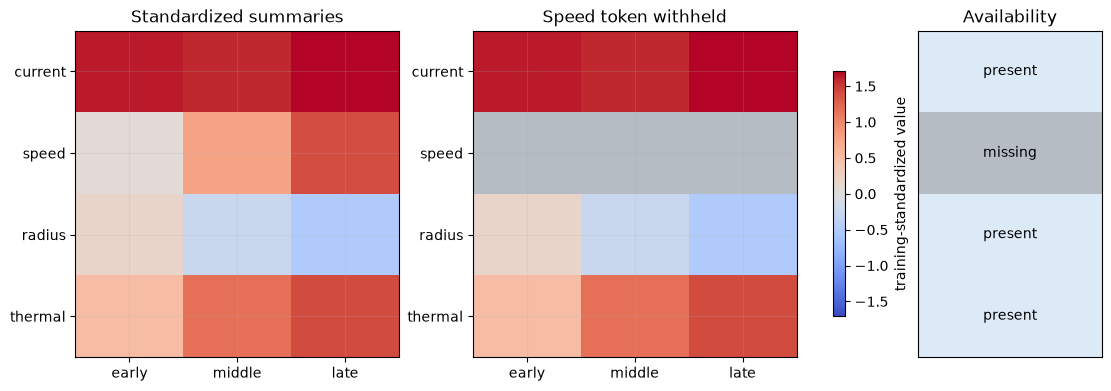

In [3]:
from matplotlib.colors import ListedColormap
v_token_values=et[0].numpy(); v_token_mask=np.array([False,True,False,False])
v_masked=np.ma.array(v_token_values,mask=np.repeat(v_token_mask[:,None],3,axis=1))
v_cmap=plt.get_cmap('coolwarm').copy(); v_cmap.set_bad('#b6bcc4')
v_bound=max(abs(v_token_values).max(),1)
v_fig,v_axes=plt.subplots(1,3,figsize=(11,3.8),gridspec_kw={'width_ratios':[3,3,1.7]},layout='constrained')
for v_ax,v_data,v_title in zip(v_axes[:2],[v_token_values,v_masked],['Standardized summaries','Speed token withheld']):
    v_im=v_ax.imshow(v_data,aspect='auto',cmap=v_cmap,vmin=-v_bound,vmax=v_bound)
    v_ax.set(xticks=[0,1,2],xticklabels=['early','middle','late'],yticks=range(4),yticklabels=['current','speed','radius','thermal'],title=v_title)
v_axes[2].imshow(v_token_mask[:,None],aspect='auto',cmap=ListedColormap(['#dceaf7','#b6bcc4']),vmin=0,vmax=1)
for v_i,v_missing in enumerate(v_token_mask): v_axes[2].text(0,v_i,'missing' if v_missing else 'present',ha='center',va='center',fontsize=10)
v_axes[2].set(xticks=[],yticks=[],title='Availability')
v_fig.colorbar(v_im,ax=v_axes[:2],shrink=.75,label='training-standardized value'); plt.show()

## 2. Build an attention encoder
The mask prevents missing tokens from serving as keys/values. Masked pooling excludes their outputs. Attention weights are a computation inside a predictive model; they are not causal explanations of the experiment.

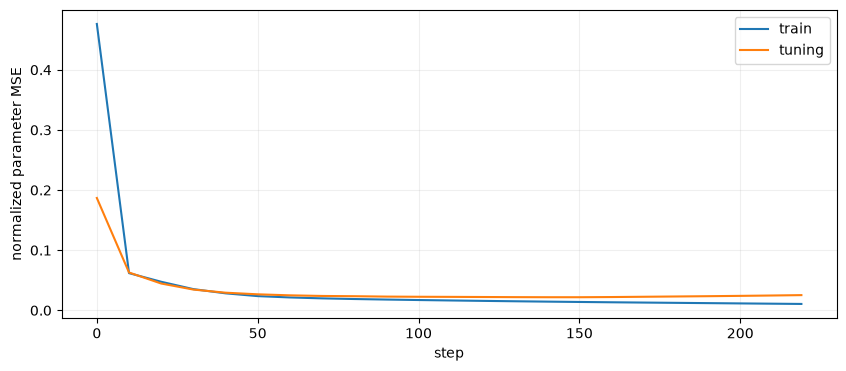

In [4]:
class DiagnosticTransformer(nn.Module):
    def __init__(self):
        super().__init__(); self.project=nn.Linear(3,32); self.modality=nn.Embedding(4,32)
        layer=nn.TransformerEncoderLayer(32,4,64,dropout=0,batch_first=True)
        self.encoder=nn.TransformerEncoder(layer,1,enable_nested_tensor=False)
        self.head=nn.Linear(32,3)
    def forward(self,values,mask):
        if mask.all(1).any(): raise ValueError('all diagnostics missing: abstain')
        values=values.masked_fill(mask[:,:,None],0)
        tokens=self.project(values)+self.modality(torch.arange(4))[None]
        hidden=self.encoder(tokens,src_key_padding_mask=mask)
        keep=(~mask).float()[:,:,None]
        return self.head((hidden*keep).sum(1)/keep.sum(1))
seed_all(11); model=DiagnosticTransformer(); optimizer=torch.optim.AdamW(model.parameters(),lr=.003)
best=float('inf'); history=[]; checkpoint=copy.deepcopy(model.state_dict())
for step in range(220):
    model.train(); optimizer.zero_grad(); loss=nn.functional.mse_loss(model(xt,mt),yt); loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(),1); optimizer.step()
    if step%10==0 or step==219:
        model.eval()
        with torch.no_grad(): val=float(nn.functional.mse_loss(model(vt,mv),yvt))
        history.append((step,float(loss.detach()),val))
        if val<best: best=val; checkpoint=copy.deepcopy(model.state_dict())
model.load_state_dict(checkpoint); model.eval()
h=np.array(history); plt.plot(h[:,0],h[:,1],label='train'); plt.plot(h[:,0],h[:,2],label='tuning'); plt.legend(); plt.xlabel('step'); plt.ylabel('normalized parameter MSE'); plt.show()

### Visual lab — Inspect the attention weights actually used by the encoder

These are attention probabilities from the trained first layer for one evaluation shot, averaged over heads. Rows are querying tokens; columns are tokens being read. In the right panel, a missing speed token cannot act as a key/value, so its column receives zero attention.

**Caution for interpretation:** weights show a model computation, not which diagnostic is physically causal. A missing token can still form a query internally, but its output is excluded by the model's masked pooling.

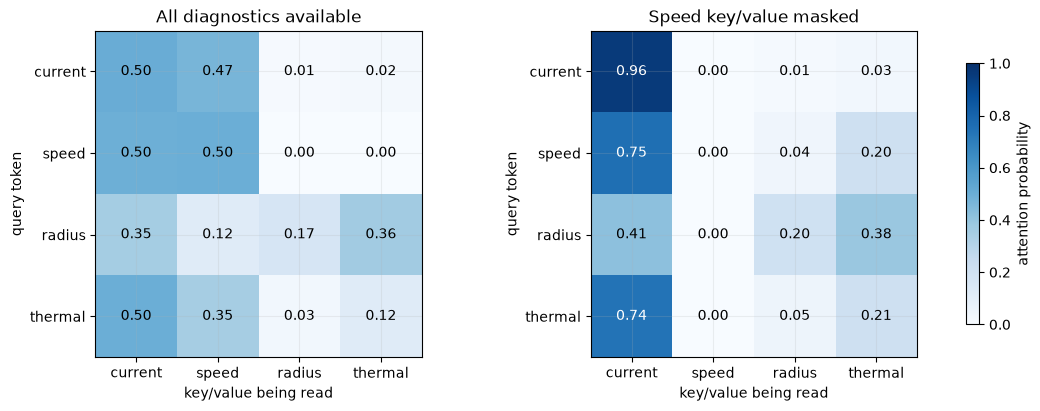

In [5]:
model.eval(); v_attention=[]
with torch.no_grad():
    for v_missing_speed in [False,True]:
        v_mask=torch.tensor([[False,v_missing_speed,False,False]])
        v_values=et[:1].masked_fill(v_mask[:,:,None],0)
        v_tokens=model.project(v_values)+model.modality(torch.arange(4))[None]
        _,v_weights=model.encoder.layers[0].self_attn(v_tokens,v_tokens,v_tokens,key_padding_mask=v_mask,need_weights=True,average_attn_weights=True)
        v_attention.append(v_weights[0].numpy())
v_fig,v_axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for v_ax,v_weights,v_title in zip(v_axes,v_attention,['All diagnostics available','Speed key/value masked']):
    v_im=v_ax.imshow(v_weights,vmin=0,vmax=1,cmap='Blues')
    for v_row in range(4):
        for v_col in range(4): v_ax.text(v_col,v_row,f'{v_weights[v_row,v_col]:.2f}',ha='center',va='center',color='white' if v_weights[v_row,v_col]>.55 else 'black')
    v_ax.set(xticks=range(4),xticklabels=['current','speed','radius','thermal'],yticks=range(4),yticklabels=['current','speed','radius','thermal'],title=v_title,xlabel='key/value being read',ylabel='query token')
v_fig.colorbar(v_im,ax=v_axes,label='attention probability',shrink=.8); plt.show()

## 3. Give ridge regression the same inputs
The regression sees zero-filled standardized summaries plus a four-bit availability vector. Its regularization is fixed at .1 for this lesson. A nonlinear Transformer is not guaranteed to beat this baseline on a small smooth inverse problem.

In [6]:
def flat_features(values,mask):
    return torch.cat([values.masked_fill(mask[:,:,None],0).flatten(1),(~mask).float(),torch.ones(len(values),1)],1)
a=flat_features(xt,mt); ridge=torch.linalg.solve(a.T@a+.1*torch.eye(a.shape[1]),a.T@yt)
@torch.no_grad()
def score_mask(mask):
    neural=model(et,mask)*span+lo; linear=flat_features(et,mask)@ridge*span+lo
    return {'attention_MAE':(neural-ye[:,:3]).abs().mean(0).tolist(),'ridge_MAE':(linear-ye[:,:3]).abs().mean(0).tolist()}
results={'all_available':score_mask(torch.zeros_like(me)),'random_missing':score_mask(me)}
for j,name in enumerate(['current','speed','radius','thermal_proxy']):
    mask=torch.zeros_like(me); mask[:,j]=True; results['without_'+name]=score_mask(mask)
display(results)

{'all_available': {'attention_MAE': [0.011086692102253437,
   0.03978370502591133,
   0.010965419933199883],
  'ridge_MAE': [0.02171354554593563,
   0.07422717660665512,
   0.01502469927072525]},
 'random_missing': {'attention_MAE': [0.020623281598091125,
   0.07209043204784393,
   0.01923377625644207],
  'ridge_MAE': [0.03107968345284462,
   0.09998217225074768,
   0.02123710885643959]},
 'without_current': {'attention_MAE': [0.03862674534320831,
   0.11048366129398346,
   0.024117372930049896],
  'ridge_MAE': [0.04812531918287277,
   0.12298014760017395,
   0.03209039568901062]},
 'without_speed': {'attention_MAE': [0.011711700819432735,
   0.11898526549339294,
   0.013068244792521],
  'ridge_MAE': [0.012797987088561058,
   0.11220681667327881,
   0.015704160556197166]},
 'without_radius': {'attention_MAE': [0.012612061575055122,
   0.04143907129764557,
   0.013646421954035759],
  'ridge_MAE': [0.014747911132872105,
   0.1031421646475792,
   0.01460347045212984]},
 'without_thermal_p

## 4. Verify that masked values cannot leak into the prediction
Corrupt missing-token values by a huge amount. Predictions should not move, because those values are erased and attention masks remove their influence. This is an interface invariant, not a benchmark score.

Maximum change from corrupted masked inputs: 0.0
All-missing record: all diagnostics missing: abstain


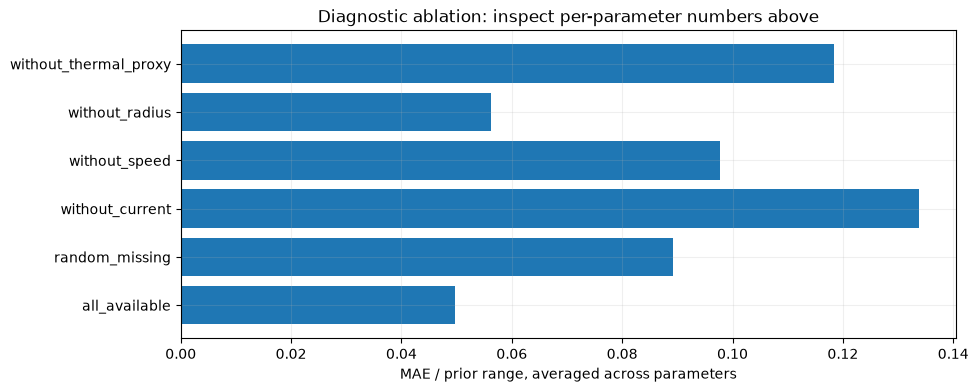

/Users/operator/Desktop/Factor/runs/world-model/11-7f361b2ac5


In [7]:
with torch.no_grad():
    corrupted=et.clone(); corrupted[me]=1e5
    difference=float((model(et,me)-model(corrupted,me)).abs().max())
print('Maximum change from corrupted masked inputs:',difference)
assert difference<1e-6
try: model(et[:1],torch.ones(1,4,dtype=torch.bool))
except ValueError as exc: print('All-missing record:',exc)
fig,ax=plt.subplots(); names=list(results)
ax.barh(names,[np.mean(np.array(results[k]['attention_MAE'])/span.numpy()) for k in names],label='attention')
ax.set(xlabel='MAE / prior range, averaged across parameters',title='Diagnostic ablation: inspect per-parameter numbers above'); plt.show()
run=save_run(ROOT,'11',{'ablation':results,'masked_value_invariance':difference},{'train_shots':384,'steps':220,'inputs':'four summary tokens'})
print(run)

### Visual lab — Which missing channel hurts which parameter?

Each number is parameter MAE divided by that parameter's prior range. This lets charge, mass and resistance share a color scale. The left panel is the Transformer; the right is ridge regression on the same permitted inputs.

**Notice:** one overall score can conceal a parameter-specific weakness. Compare the mass column when speed is missing.

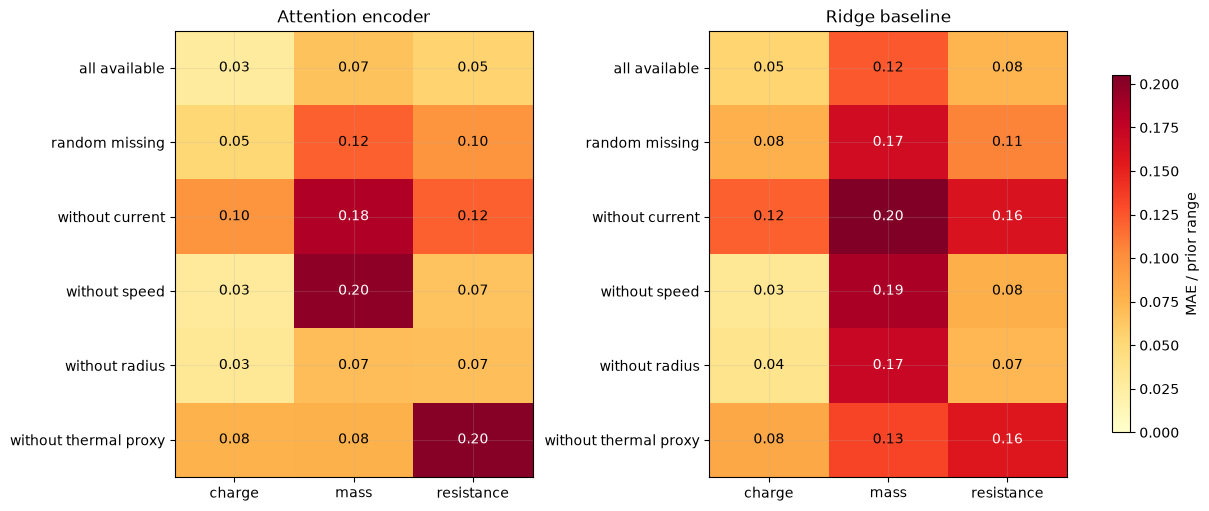

In [8]:
v_names=list(results); v_matrices=[np.array([results[v_name][v_method] for v_name in v_names])/span.numpy() for v_method in ['attention_MAE','ridge_MAE']]
v_max=max(v_matrix.max() for v_matrix in v_matrices)
v_fig,v_axes=plt.subplots(1,2,figsize=(12,5),layout='constrained')
for v_ax,v_matrix,v_title in zip(v_axes,v_matrices,['Attention encoder','Ridge baseline']):
    v_im=v_ax.imshow(v_matrix,aspect='auto',vmin=0,vmax=v_max,cmap='YlOrRd')
    for v_i in range(len(v_names)):
        for v_j in range(3): v_ax.text(v_j,v_i,f'{v_matrix[v_i,v_j]:.2f}',ha='center',va='center',color='white' if v_matrix[v_i,v_j]>.7*v_max else 'black')
    v_ax.set(xticks=range(3),xticklabels=PARAM_NAMES[:3],yticks=range(len(v_names)),yticklabels=[v_name.replace('_',' ') for v_name in v_names],title=v_title)
v_fig.colorbar(v_im,ax=v_axes,label='MAE / prior range',shrink=.8); plt.show()

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Replace the summary-token encoder with waveform CNNs and image patches, while preserving the observation boundary.
2. Change missingness to depend on signal strength; random-dropout training may not generalize.
3. Predict a probability distribution rather than a point estimate and recalibrate separately for missing-channel regimes.